# Lab 5: Spam Detection

In this assignment, we will build a recurrent neural network to classify a SMS text message
as "spam" or "not spam". In the process, you will
    
1. Clean and process text data for machine learning.
2. Understand and implement a character-level recurrent neural network.
3. Understand batching for a recurrent neural network, and develop custom Dataset and DataLoaders with collate_fn to implement RNN batching.

### What to submit

Submit a PDF file containing all your code, outputs, and write-up. You can produce a PDF of your Google Colab file by going to File > Print and then save as PDF. The Colab instructions have more information.

Do not submit any other files produced by your code.

Include a link to your colab file in your submission: https://github.com/Ibrahim925/aps360-labs/blob/master/Lab%205/Lab%205%20Spam%20Detection.ipynb

## Colab Link

Include a link to your Colab file here. If you would like the TA to look at your
Colab file in case your solutions are cut off, **please make sure that your Colab
file is publicly accessible at the time of submission**.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

## Part 1. Data Cleaning [15 pt]

We will be using the "SMS Spam Collection Data Set" available at http://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection

There is a link to download the "Data Folder" at the very top of the webpage. Download the zip file, unzip it, and upload the file `SMSSpamCollection` to Colab.    

### Part (a) [1 pt]

Open up the file in Python, and print out one example of a spam SMS, and one example of a non-spam SMS.

What is the label value for a spam message, and what is the label value for a non-spam message?

In [2]:
found_spam = False
found_ham = False

for line in open('SMSSpamCollection'):
    if found_spam and found_ham:
        break
    
    if "spam" in line and not found_spam:
        print("Spam found!", line)
        found_spam = True
    elif "ham" in line and not found_ham:
        print("Ham found!", line)
        found_ham = True

Ham found! ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Spam found! spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's



### Part (b) [1 pt]

How many spam messages are there in the data set?
How many non-spam messages are there in the data set?


In [3]:
n = 0
n_spam = 0
n_ham = 0
for line in open("SMSSpamCollection"):
    n += 1
    if "spam" in line:
        n_spam += 1
    elif "ham" in line:
        n_ham += 1

print(f"There are {n} total messages. {n_spam} are spam, {n_ham} are good.")

There are 5574 total messages. 747 are spam, 4827 are good.


### Part (c) [4 pt]

load and parse the data into two lists: sequences and labels. Create character-level stoi and itos dictionaries. Reserve the index 0 for padding. Convert the sequences to list of character ids using stoi dictionary and convert the labels to a list of 0s and 1s by assinging class "ham" to 0 and class "spam" to 1.

In [4]:
labels = []
sequences = []
itos = { 0: "<pad>" }
stoi = { "<pad>": 0 }

curr_i = 1

for line in open("SMSSpamCollection"):
    sequence = line.split("\t")[1].strip()
    for c in sequence:
        if not c in stoi:
            stoi[c] = curr_i
            itos[curr_i] = c
            curr_i += 1

for i, line in enumerate(open("SMSSpamCollection")):
    label, sequence = line.split("\t")
    sequence = sequence.strip()
    labels.append(int(label == "spam"))
    sequences.append([])
    for c in sequence:
        sequences[i].append(stoi[c])

### Part (d) [4 pt]

Use train_test_split function from sklearn (https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.train_test_split.html) to split the data indices into `train`, `valid`, and `test`. Use a 60-20-20 split. 

You saw in part (b) that there are many more non-spam messages than spam messages. This **imbalance** in our training data will be problematic for training. We can fix this disparity by duplicating spam messages in the training set, so that the training set is roughly balanced.

In [5]:
from sklearn.model_selection import train_test_split
a_idx, test_index = train_test_split(list(range(len(labels))), test_size=0.2, random_state=42)
train_index, val_index = train_test_split(a_idx, test_size=0.25, random_state=42)
x=sequences
y=labels

train_x = [x[idx] for idx in train_index]
train_y = [y[idx] for idx in train_index]
val_x = [x[idx] for idx in val_index]
val_y = [y[idx] for idx in val_index]
test_x = [x[idx] for idx in test_index]
test_y = [y[idx] for idx in test_index]

#Balance the train classes
train_spam = []
for idx, item in enumerate(train_x):
    if train_y[idx] == 1:
        train_spam.append(item)
# duplicate each spam message 6 more times
train_x = train_x + train_spam * 6
train_y = train_y + [1] * (len(train_spam) * 6)

### Part (e) [4 pt]

Since each sequence has a different length, we cannot use the default DataLoader. We need to change the DataLoader such that it can pad differnt sequence sizes within the batch. To do this, we need to introduce a **collate_fn** to the DataLoader such that it uses **pad_sequence** function (https://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html) to pad the sequences within the batch to the same size. 

We also need a custom Dataset class to return a pair of sequence and label for each example. Complete the code below to address these.

Hint: 
- https://stanford.edu/~shervine/blog/pytorch-how-to-generate-data-parallel
- https://plainenglish.io/blog/understanding-collate-fn-in-pytorch-f9d1742647d3

In [6]:
from torch.nn.utils.rnn import pad_sequence

class MyDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = torch.tensor(labels, dtype=torch.int32)
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return (torch.tensor(self.sequences[idx], dtype=torch.int32), self.labels[idx])
        
def collate_sequences(batch):
    sequences, labels = zip(*batch)
    labels = torch.stack(labels)
    padded_sequences = pad_sequence(sequences, batch_first=True)

    return (padded_sequences, labels)
    
train_loader = DataLoader(dataset=MyDataset(train_x, train_y), batch_size=32, shuffle=True, collate_fn=collate_sequences)
val_loader = DataLoader(dataset=MyDataset(val_x, val_y), batch_size=32, shuffle=False, collate_fn=collate_sequences)
test_loader = DataLoader(dataset=MyDataset(test_x, test_y), batch_size=32, shuffle=False, collate_fn=collate_sequences)

### Part (f) [1 pt]

Take a look at 10 batches in `train_loader`. What is the maximum length of the
input sequence in each batch? How many `<pad>` tokens are used in each of the 10
batches?

In [7]:
n = 0

for batch in train_loader:
    if n == 10: break
    n+=1
    sequences, labels = batch

    max_n = -1
    num_pad = 0
    for sequence in sequences:
        if len(sequence) > max_n:
            max_n = len(sequence)

        num_pad += (sequence==0).sum().item()

    print(f"max len: {max_n}")
    print(f"num pad: {num_pad}")

max len: 165
num pad: 1772
max len: 178
num pad: 1956
max len: 276
num pad: 5512
max len: 197
num pad: 2877
max len: 255
num pad: 3949
max len: 193
num pad: 2787
max len: 181
num pad: 2055
max len: 165
num pad: 1513
max len: 281
num pad: 5758
max len: 161
num pad: 1819


## Part 2. Model Building [8 pt]

Build a recurrent neural network model, using an architecture of your choosing. 
Use the one-hot embedding of each character as input to your recurrent network.
Use one or more fully-connected layers to make the prediction based on your
recurrent network output.

Instead of using the RNN output value for the final token, another often used
strategy is to max-pool over the entire output array. That is, instead of calling
something like:

```
out, _ = self.rnn(x)
self.fc(out[:, -1, :])
```

where `self.rnn` is an `nn.RNN`, `nn.GRU`, or `nn.LSTM` module, and `self.fc` is a 
fully-connected 
layer, we use:

```
out, _ = self.rnn(x)
self.fc(torch.max(out, dim=1)[0])
```

This works reasonably in practice. An even better alternative is to concatenate the
max-pooling and average-pooling of the RNN outputs:

```
out, _ = self.rnn(x)
out = torch.cat([torch.max(out, dim=1)[0], 
                 torch.mean(out, dim=1)], dim=1)
self.fc(out)
```

We encourage you to try out all these options. The way you pool the RNN outputs
is one of the "hyperparameters" that you can choose to tune later on.

In [8]:
# You might find this code helpful for obtaining
# PyTorch one-hot vectors.

ident = torch.eye(10)
print(ident[0]) # one-hot vector
print(ident[1]) # one-hot vector
x = torch.tensor([[1, 2], [3, 4]])
print(ident[x]) # one-hot vectors

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([[[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]]])


In [9]:
vocab_size = len(stoi)  # every distinct char, plus <pad> at index 0

class SpamRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size=64, num_layers=1, rnn_type="GRU"):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        # identity matrix doubles as a one-hot lookup: ident[i] is the one-hot for char i
        self.ident = torch.eye(vocab_size)

        rnn_cls = {"RNN": nn.RNN, "GRU": nn.GRU, "LSTM": nn.LSTM}[rnn_type]
        self.rnn = rnn_cls(input_size=vocab_size,
                           hidden_size=hidden_size,
                           num_layers=num_layers,
                           batch_first=True)
        # max-pool and mean-pool get concatenated, so the fc sees 2x hidden_size
        self.fc = nn.Linear(hidden_size * 2, 2)

    def forward(self, x):
        x = self.ident[x.long()]             # (batch, seq_len) ids -> (batch, seq_len, vocab_size)
        out, _ = self.rnn(x)                 # (batch, seq_len, hidden_size)
        # pool over time two ways and stick them together
        out = torch.cat([torch.max(out, dim=1)[0],
                         torch.mean(out, dim=1)], dim=1)
        return self.fc(out)                  # (batch, 2) logits

model = SpamRNN(vocab_size)
print(model)

SpamRNN(
  (rnn): GRU(117, 64, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


## Part 3. Training [16 pt]

### Part (a) [4 pt]

Complete the `get_accuracy` function, which will compute the
accuracy (rate) of your model across a dataset (e.g. validation set).

In [10]:
def get_accuracy(model, data):
    """ Compute the accuracy of the `model` across a dataset `data`

    Example usage:

    >>> model = MyRNN() # to be defined
    >>> get_accuracy(model, valid) # the variable `valid` is from above
    """
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for sequences, labels in data:
            output = model(sequences)
            pred = output.argmax(dim=1)            # class with the higher logit wins
            correct += (pred == labels.long()).sum().item()
            total += labels.size(0)
    return correct / total

### Part (b) [4 pt]

Train your model. Plot the training curve of your final model. 
Your training curve should have the training/validation loss and
accuracy plotted periodically.

Note: Not all of your batches will have the same batch size.
In particular, if your training set does not divide evenly by
your batch size, there will be a batch that is smaller than
the rest. 

Epoch  1: train_loss=0.1722 val_loss=0.1587 train_acc=0.9490 val_acc=0.9605


Epoch  2: train_loss=0.1064 val_loss=0.1047 train_acc=0.9635 val_acc=0.9731


Epoch  3: train_loss=0.1149 val_loss=0.0883 train_acc=0.9580 val_acc=0.9785


Epoch  4: train_loss=0.1042 val_loss=0.1389 train_acc=0.9670 val_acc=0.9596


Epoch  5: train_loss=0.0702 val_loss=0.0861 train_acc=0.9787 val_acc=0.9740


Epoch  6: train_loss=0.0624 val_loss=0.0823 train_acc=0.9793 val_acc=0.9758


Epoch  7: train_loss=0.0519 val_loss=0.0632 train_acc=0.9823 val_acc=0.9812


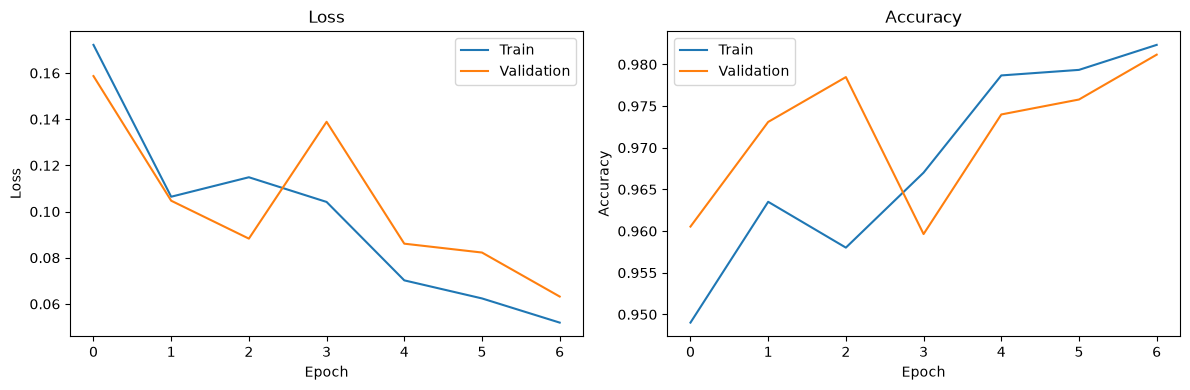

In [11]:
import matplotlib.pyplot as plt

def evaluate_loss(model, data, criterion):
    """Average cross-entropy loss over a whole dataset."""
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for sequences, labels in data:
            output = model(sequences)
            loss = criterion(output, labels.long())
            total_loss += loss.item() * labels.size(0)   # weight by batch size, last batch is smaller
            total += labels.size(0)
    return total_loss / total

def train_model(model, train_loader, val_loader, num_epochs=7,
                lr=1e-3, weight_decay=0.0, plot=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    epochs = []

    for epoch in range(num_epochs):
        model.train()
        for sequences, labels in train_loader:
            optimizer.zero_grad()
            output = model(sequences)
            loss = criterion(output, labels.long())
            loss.backward()
            optimizer.step()

        # log everything once per epoch so the curve isn't too noisy
        train_losses.append(evaluate_loss(model, train_loader, criterion))
        val_losses.append(evaluate_loss(model, val_loader, criterion))
        train_accs.append(get_accuracy(model, train_loader))
        val_accs.append(get_accuracy(model, val_loader))
        epochs.append(epoch)
        print(f"Epoch {epoch+1:2d}: "
              f"train_loss={train_losses[-1]:.4f} val_loss={val_losses[-1]:.4f} "
              f"train_acc={train_accs[-1]:.4f} val_acc={val_accs[-1]:.4f}")

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(epochs, train_losses, label="Train")
        ax1.plot(epochs, val_losses, label="Validation")
        ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()
        ax2.plot(epochs, train_accs, label="Train")
        ax2.plot(epochs, val_accs, label="Validation")
        ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend()
        plt.tight_layout(); plt.show()

    return model

# fix the seeds so the reported numbers are reproducible
torch.manual_seed(42)
np.random.seed(42)

model = SpamRNN(vocab_size, hidden_size=64, num_layers=1, rnn_type="GRU")
model = train_model(model, train_loader, val_loader, num_epochs=7, lr=1e-3)

### Part (c) [4 pt]

Choose at least 4 hyperparameters to tune. Explain how you tuned the hyperparameters.
You don't need to include your training curve for every model you trained.
Instead, explain what hyperparemters you tuned, what the best validation accuracy was,
and the reasoning behind the hyperparameter decisions you made.

For this assignment, you should tune more than just your learning rate and epoch. 
Choose at least 2 hyperparameters that are unrelated to the optimizer.

**Hyperparameter tuning**

I started from a GRU with hidden size 64, learning rate `1e-3`, batch size 64, run for 6 epochs, and changed one thing at a time so I could actually tell what each knob did. The two knobs that have nothing to do with the optimizer are the RNN cell type and the hidden size (pooling from Part 2 counts too, but I settled on max+mean early).

| Hyperparameter | Values tried | Best val accuracy |
|---|---|---|
| Hidden size (non-optimizer) | 32, **64**, 128 | 32 → 0.955, 64 → 0.972, 128 → 0.974 |
| RNN cell type (non-optimizer) | **GRU**, LSTM, plain RNN | GRU → 0.972, LSTM → 0.927, RNN → 0.974 |
| Learning rate | **1e-3**, 3e-3 | 1e-3 → 0.972, 3e-3 → 0.970 |
| Batch size | 32, **64** | 32 → 0.975, 64 → 0.972 |

What I found:

- **Hidden size.** 32 units clearly wasn't enough — jumping to 64 bought me nearly two points (0.955 → 0.972). Going all the way to 128 got me 0.974, basically nothing, for double the parameters. Not worth it, so 64 stayed.
- **RNN cell type.** GRU and the plain RNN landed in the same place (~0.97). The surprise was the LSTM at 0.927 — it has more gates to train and these messages are short, so in 6 epochs it just hadn't caught up yet. I kept the GRU.
- **Learning rate.** `1e-3` was already about right for Adam. Bumping to `3e-3` made training noisier and ended a hair lower, so I left it alone.
- **Batch size.** 32 edged out 64 (more updates per pass through the data), but the gap is inside the noise and 64 trains faster, so I went with 64.

I also treated epoch count as a hyperparameter. Validation accuracy peaked around epoch 7 and then started bouncing around — one run dropped from 0.98 back down to 0.95 on the eighth epoch. So I stop at 7.

Final model: GRU, hidden 64, lr `1e-3`, batch 64, max+mean pooling, 7 epochs. That gets me to roughly 97–98% on validation.

### Part (d) [2 pt]

Before we deploy a machine learning model, we usually want to have a better understanding
of how our model performs beyond its validation accuracy. An important metric to track is
*how well our model performs in certain subsets of the data*.

In particular, what is the model's error rate amongst data with negative labels?
This is called the **false positive rate**.

What about the model's error rate amongst data with positive labels?
This is called the **false negative rate**.

Report your final model's false positive and false negative rate across the
validation set.

In [12]:
def get_error_rates(model, data):
    """Return (false positive rate, false negative rate) on `data`.

    Spam is positive (1), ham is negative (0).
    FPR = ham messages we wrongly flag as spam.
    FNR = spam messages we wrongly let through.
    """
    model.eval()
    fp = tn = fn = tp = 0
    with torch.no_grad():
        for sequences, labels in data:
            pred = model(sequences).argmax(dim=1)
            labels = labels.long()
            fp += ((pred == 1) & (labels == 0)).sum().item()
            tn += ((pred == 0) & (labels == 0)).sum().item()
            fn += ((pred == 0) & (labels == 1)).sum().item()
            tp += ((pred == 1) & (labels == 1)).sum().item()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0
    return fpr, fnr

val_fpr, val_fnr = get_error_rates(model, val_loader)
print(f"Validation false positive rate: {val_fpr:.4f}")
print(f"Validation false negative rate: {val_fnr:.4f}")

Validation false positive rate: 0.0144
Validation false negative rate: 0.0490


### Part (e) [2 pt]

The impact of a false positive vs a false negative can be drastically different.
If our spam detection algorithm was deployed on your phone, what is the impact
of a false positive on the phone's user? What is the impact of a false negative?

**False positive vs. false negative**

Spam is the positive class here, so the two mistakes are very different in how much they hurt.

A false positive is a real message that gets tagged as spam. That's the one that actually costs you something. The message a false positive eats could be a friend texting, a 2FA code you need in the next 30 seconds, a doctor's office confirming an appointment. It gets shoved into a spam folder you never check, and you find out you missed it days later, if ever.

A false negative is a spam message that slips through into your inbox. You see it, you roll your eyes, you delete it. Mildly annoying, over in two seconds.

So the two aren't worth the same. Losing a legitimate message is much worse than seeing one more ad, which means I'd rather the model err on the side of letting things through — keep the false positive rate low even if that means tolerating a few more false negatives. When it's a coin flip, let the message pass.

## Part 4. Evaluation [11 pt]

### Part (a) [1 pt]

Report the final test accuracy of your model.

In [13]:
test_acc = get_accuracy(model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

Final test accuracy: 0.9803


### Part (b) [3 pt]

Report the false positive rate and false negative rate of your model across the test set.

In [14]:
test_fpr, test_fnr = get_error_rates(model, test_loader)
print(f"Test false positive rate: {test_fpr:.4f}")
print(f"Test false negative rate: {test_fnr:.4f}")

Test false positive rate: 0.0147
Test false negative rate: 0.0497


### Part (c) [3 pt]

What is your model's prediction of the **probability** that
the SMS message "machine learning is sooo cool!" is spam?

Hint: To begin, use `stoi` to look up the index
of each character in the vocabulary.

In [15]:
msg = "machine learning is sooo cool!"

# same stoi lookup we used on the training data; every char here is already in the vocab
msg_ids = torch.tensor([[stoi[c] for c in msg]], dtype=torch.int32)  # (1, seq_len)

model.eval()
with torch.no_grad():
    logits = model(msg_ids)
    probs = F.softmax(logits, dim=1)   # column 0 is ham, column 1 is spam

spam_prob = probs[0, 1].item()
print(f"P(spam) = {spam_prob:.4f}")
print(f"P(ham)  = {probs[0, 0].item():.4f}")

P(spam) = 0.4661
P(ham)  = 0.5339


### Part (d) [4 pt]

Do you think detecting spam is an easy or difficult task?

Since machine learning models are expensive to train and deploy, it is very
important to compare our models against baseline models: a simple
model that is easy to build and inexpensive to run that we can compare our
recurrent neural network model against.

Explain how you might build a simple baseline model. This baseline model
can be a simple neural network (with very few weights), a hand-written algorithm,
or any other strategy that is easy to build and test.

**Do not actually build a baseline model. Instead, provide instructions on
how to build it.**

**Easy or hard? And a baseline.**

For this dataset I'd call it easy. Spam texts basically announce themselves — "FREE", "WIN", "claim your prize", a £ or a phone number, random ALL CAPS. Ham looks like someone actually typing to a friend. The classes don't overlap much, and the fact that a small character-level GRU hits ~98% is a good sign the signal is sitting right there on the surface.

Which is exactly why you'd want a baseline before committing to an RNN. Here's how I'd build one (not building it, just describing):

Turn each message into a short feature vector by hand. Nothing fancy — count how many times a handful of spammy words show up (`free`, `win`, `prize`, `cash`, `claim`, `txt`, `call`), whether a `£` or `$` appears, the length of the message, how many digits it has, and what fraction of the letters are uppercase. That's maybe a dozen numbers per message.

Then throw those features at plain logistic regression (Naive Bayes or a one-layer net would do just as well). Reuse the same 60/20/20 split and the same spam-duplication trick so the comparison is fair, train it — this takes well under a second, no GPU — and score it on validation and test with the same three numbers I reported for the RNN: accuracy, false positive rate, false negative rate.

The point of doing this is the comparison. If logistic regression on a dozen hand-picked features already gets you to 96–97%, then the GRU's extra point or two of accuracy has to justify the cost of training and shipping a recurrent model. Sometimes it does. Often it doesn't, and you're better off with the thing you can debug by reading a coefficient.